# 04 — Zero-Shot Classification

Classifica os 500 tweets da amostra sem exemplos no prompt.

- Modelo: **qwen3.5:9b** (`think: false`)
- Saída: `results/zero_shot_results.csv`
- Métrica principal: **F1-macro**

In [1]:
import time
import re
from pathlib import Path

import polars as pl
import requests
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

OLLAMA_BASE = "http://127.0.0.1:11434"
MODEL = "qwen3.5:9b"
VALID_LABELS = {"NOT_TOXIC", "OBSCENE", "INSULT", "HOMOPHOBIA", "RACISM", "MISOGYNY", "XENOPHOBIA"}

Path("../results").mkdir(exist_ok=True)

In [2]:
sample = pl.read_csv("../data/sample/toldBr_sample_500.csv")
print(f"Tweets: {len(sample)}")
print(sample["label"].value_counts().sort("label"))

Tweets: 500
shape: (6, 2)
┌────────────┬───────┐
│ label      ┆ count │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ homophobia ┆ 4     │
│ insult     ┆ 36    │
│ misogyny   ┆ 1     │
│ not_toxic  ┆ 403   │
│ obscene    ┆ 55    │
│ xenophobia ┆ 1     │
└────────────┴───────┘


In [3]:
def build_prompt(tweet: str) -> str:
    return (
        "Você é um sistema de moderação de conteúdo em português brasileiro.\n\n"
        "Classifique o comentário abaixo em UMA das categorias:\n"
        "- NOT_TOXIC: sem ofensas, críticas construtivas ou conteúdo neutro\n"
        "- OBSCENE: palavrões, linguagem vulgar ou conteúdo sexualmente explícito\n"
        "- INSULT: ataque pessoal ou xingamento direcionado a indivíduo(s)\n"
        "- HOMOPHOBIA: discurso de ódio contra pessoas LGBTQIA+\n"
        "- RACISM: discurso de ódio baseado em raça ou etnia\n"
        "- MISOGYNY: discurso de ódio contra mulheres\n"
        "- XENOPHOBIA: preconceito contra pessoas de outras regiões ou países\n\n"
        "Regra: se o comentário for ofensivo mas não claramente NOT_TOXIC, "
        "escolha a categoria tóxica mais específica.\n"
        "Responda APENAS com o nome da categoria.\n\n"
        f"Comentário: {tweet}\n"
        "Classificação:"
    )


def parse_label(response: str) -> str:
    text = response.strip().upper().replace(" ", "_")
    for label in VALID_LABELS:
        if label in text:
            return label.lower()
    return "unknown"

## Classificar 500 tweets

In [4]:
resultados = []
t_inicio = time.time()

for i, row in enumerate(sample.iter_rows(named=True)):
    payload = {
        "model": MODEL,
        "prompt": build_prompt(row["text"]),
        "stream": False,
        "think": False,
    }
    r = requests.post(f"{OLLAMA_BASE}/api/generate", json=payload)
    data = r.json()
    predicao = parse_label(data["response"])
    tps = data["eval_count"] / (data["eval_duration"] / 1e9)

    resultados.append({
        "text": row["text"],
        "label": row["label"],
        "predicao": predicao,
        "resposta_raw": data["response"].strip(),
        "tokens_s": round(tps, 1),
        "latencia_s": round(time.time() - t_inicio, 2),
    })

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t_inicio
        print(f"{i+1}/500 — {elapsed:.0f}s — último: {predicao}")

print(f"\nConcluído em {time.time() - t_inicio:.0f}s")

50/500 — 17s — último: obscene


100/500 — 31s — último: not_toxic


150/500 — 45s — último: racism


200/500 — 58s — último: not_toxic


250/500 — 72s — último: not_toxic


300/500 — 86s — último: not_toxic


350/500 — 99s — último: not_toxic


400/500 — 113s — último: misogyny


450/500 — 127s — último: not_toxic


500/500 — 140s — último: homophobia

Concluído em 140s


In [5]:
df = pl.DataFrame(resultados)
df.write_csv("../results/zero_shot_results.csv")
print("Salvo em results/zero_shot_results.csv")
print(f"UNKNOWN: {(df['predicao'] == 'UNKNOWN').sum()}")

Salvo em results/zero_shot_results.csv
UNKNOWN: 0


## Métricas

In [6]:
y_true = df["label"].to_list()
y_pred = df["predicao"].to_list()

f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
print(f"F1-macro: {f1_macro:.4f}\n")
print(classification_report(y_true, y_pred, zero_division=0))

F1-macro: 0.2673

              precision    recall  f1-score   support

  homophobia       0.33      0.50      0.40         4
      insult       0.41      0.25      0.31        36
    misogyny       0.00      0.00      0.00         1
   not_toxic       0.90      0.71      0.79       403
     obscene       0.27      0.58      0.37        55
      racism       0.00      0.00      0.00         0
  xenophobia       0.00      0.00      0.00         1

    accuracy                           0.66       500
   macro avg       0.27      0.29      0.27       500
weighted avg       0.79      0.66      0.70       500



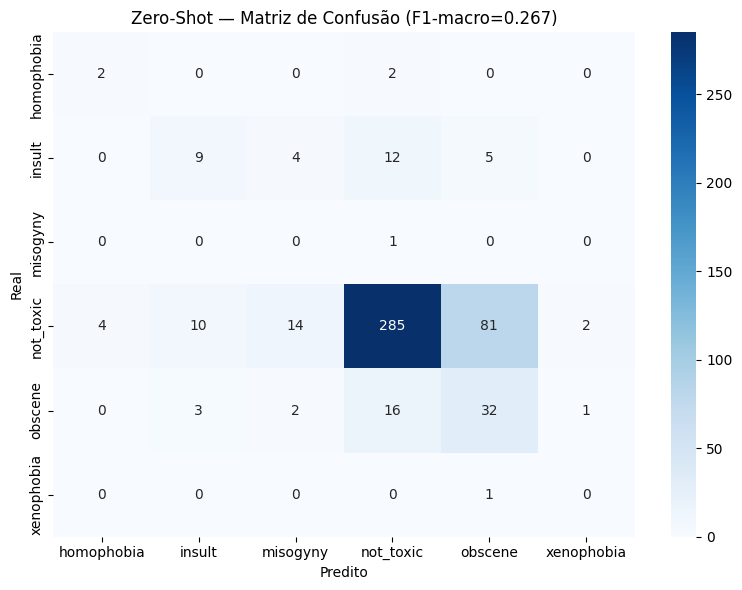

In [7]:
labels = sorted(set(y_true))
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title(f"Zero-Shot — Matriz de Confusão (F1-macro={f1_macro:.3f})")
plt.tight_layout()
plt.savefig("../results/zero_shot_confusion.png", dpi=150)
plt.show()